# PPO algorithm results validation

## Imports

In [1]:
1 + 1

2

In [2]:
import os
import sys

sys.path.append("..")

In [3]:
# python -m build --sdist
# %pip install rl_trading-0.0.1.tar.gz

In [4]:
from copy import deepcopy

import dill
import numpy as np
import pandas as pd
import ray
import torch
import matplotlib.pyplot as plt

from pprint import pprint
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.models import ModelCatalog
from ray.rllib.utils.metrics import ENV_RUNNER_RESULTS
from ray.tune.registry import register_env
from tqdm import tqdm, trange

In [5]:
# Comment next two lines to run in collab
%load_ext autoreload
%autoreload 2

from rl_trading.environments.fx_environment import FxTradingEnv
from rl_trading.models.fx_model import FXModel
from rl_trading.environments.base_environment import (
    DEFAULT_TRADING_PARAMS,
)

## Todo

- Increase number of trading days to 5
- Try SAC and DreamerV3

---
## Load and prepare historical data

In [6]:
# comment for collab
data_folder = "C:\\Users\\Ivan\\rl_trading\\data\\"
# data_folder = ""

In [7]:
with open(f"{data_folder}preprocessed_data.pkl", "rb") as f:
    historical_data = dill.load(f)

In [8]:
_, _, validate_prices, validate_data = historical_data.values()

What to trade:

In [9]:
TICKER_SET = (
    "EURJPY",
    "EURUSD",
    "SGDJPY",
    "USDJPY",
    "USDSGD",
)

In [10]:
del historical_data

---
## Trading config

### Trading setup:

1. Algorithm starts with US dollars only
2. It trades minutely for one day and then converts all positions to US dollars to avoid leaving open position during the night
3. All transaction costs, slippage and fees are accounted in one trade fee: 1 bps per trade (can be changed)
4. We assume the market is liquid enough for our volume and disregard trading book structure

In [11]:
CURRENT_PORTFOLIO = {
    "USD": 10_000,
    "EUR": 10_000,
    "SGD": 10_000,
    "JPY": 1_000_000,
}

In [12]:
VALIDATION_TRADING_PARAMS = DEFAULT_TRADING_PARAMS.copy()
VALIDATION_TRADING_PARAMS["no_trade_penalty"] = 0
VALIDATION_TRADING_PARAMS["action_penalty"] = 0
VALIDATION_TRADING_PARAMS["max_delta_in_weights"] = (
    0.99  # Not 1 for algorithm stability
)
VALIDATION_TRADING_PARAMS["reward"] = "total_profit"

In [13]:
ENV_CONFIG = {
    "historical_prices": validate_prices,
    "features_dataset": validate_data,
    "initial_portfolio": CURRENT_PORTFOLIO,
    "ticker_set": TICKER_SET,
    "start_datetime": None,  # pd.Timestamp("2023-01-03 09:00:00"),
    "episode_length_days": 1,
    "trading_params": VALIDATION_TRADING_PARAMS,
}

In [14]:
max(validate_prices.keys())

'2024-12-31 16:58:00'

---
## Validation part

In [59]:
class RandomModel:
    def __init__(self, num_ccy: int, max_w: float):
        self.num_ccy = num_ccy
        self.max_w = max_w
        np.random.seed(42)

    def __call__(self, *args, **kwargs):
        return 2 * torch.rand(self.num_ccy) - 1, {}

In [63]:
def run_validation(
    model, fx_env: FxTradingEnv, num_ccy: int, n_episodes: int = 100, seed: int = 42
):
    np.random.seed(seed)

    execution_times = []
    portfolio_pos = []
    total_rewards = []

    for _ in trange(n_episodes):

        state, info = fx_env.reset()

        start_time = pd.Timestamp.now()
        done = False

        current_portfolio = []
        total_reward = []

        while not done:

            torch_state = torch.from_numpy(state).type(torch.float32)

            with torch.no_grad():
                action, _ = model(
                    input_dict={"obs": torch_state}, state=[], seq_lens=None
                )

            action = action.detach().numpy()[:num_ccy]
            state, reward, terminated, truncated, info = fx_env.step(action)
            done = terminated or truncated

            current_portfolio.append(deepcopy(info["portfolio"]))
            total_reward.append(reward)

        execution_times.append((pd.Timestamp.now() - start_time).total_seconds())
        total_rewards.append(deepcopy(total_reward))
        portfolio_pos.append(deepcopy(current_portfolio))

    total_rewards = [np.array(x) for x in total_rewards]
    return n_episodes, total_rewards, portfolio_pos

In [41]:
fx_env = FxTradingEnv(**ENV_CONFIG)

In [42]:
fx_env.preprocess_data()

In [32]:
pprint(fx_env.trading_params)

{'action_penalty': 0,
 'base_currency': 'USD',
 'long_only': True,
 'max_delta_in_weights': 0.99,
 'no_trade_penalty': 0,
 'reward': 'total_profit',
 'sharpe_eta': 0.1,
 'slippage': (0.0001, 0.0002),
 'trade_fee': 0.0001}


In [64]:
max_w = fx_env.trading_params["max_delta_in_weights"]
num_ccy = len(TICKER_SET)

## Random actions

In [65]:
random_model = RandomModel(num_ccy=num_ccy, max_w=max_w)

In [66]:
random_execution_time, random_rewards, random_pos = run_validation(
    model=random_model, fx_env=fx_env, n_episodes=100, num_ccy=num_ccy
)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:33<00:00,  3.01it/s]


---
## 1-Day model


In [67]:
MODEL_NAME = "MODEL_WEIGHTS_1_MIN_1_DAY.pth"

In [68]:
fx_env = FxTradingEnv(**ENV_CONFIG)
fx_env.preprocess_data()

In [69]:
state_dict = torch.load(f"../trained_models/{MODEL_NAME}")

In [70]:
trained_model = FXModel(
    obs_space=fx_env.observation_space,
    action_space=fx_env.action_space,
    num_outputs=num_ccy * 2,
    model_config={},
    name="FXModel",  # any name if fine
)

In [71]:
trained_model.load_state_dict(state_dict)
trained_model.eval()

FXModel(
  (main_net): Sequential(
    (0): Linear(in_features=36, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.2, inplace=False)
  )
  (mean_net): Sequential(
    (0): Linear(in_features=64, out_features=5, bias=True)
    (1): Tanh()
  )
  (log_std_net): Sequential(
    (0): Linear(in_features=64, out_features=5, bias=True)
  )
  (value_net): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=1, bi

In [72]:
execution_time_1d, rewards_1d, pos_1d = run_validation(
    model=trained_model, fx_env=fx_env, n_episodes=100, num_ccy=num_ccy
)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:15<00:00,  1.36s/it]


---
## 10-Day model

In [73]:
MODEL_NAME = "MODEL_WEIGHTS_1_MIN_10_DAY.pth"

In [74]:
state_dict = torch.load(f"../trained_models/{MODEL_NAME}")

In [75]:
trained_model.load_state_dict(state_dict)
trained_model.eval()

FXModel(
  (main_net): Sequential(
    (0): Linear(in_features=36, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.2, inplace=False)
  )
  (mean_net): Sequential(
    (0): Linear(in_features=64, out_features=5, bias=True)
    (1): Tanh()
  )
  (log_std_net): Sequential(
    (0): Linear(in_features=64, out_features=5, bias=True)
  )
  (value_net): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=1, bi

In [76]:
execution_time_10d, rewards_10d, pos_10d = run_validation(
    model=trained_model, fx_env=fx_env, n_episodes=100, num_ccy=num_ccy
)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:24<00:00,  1.44s/it]


---
## Graphs

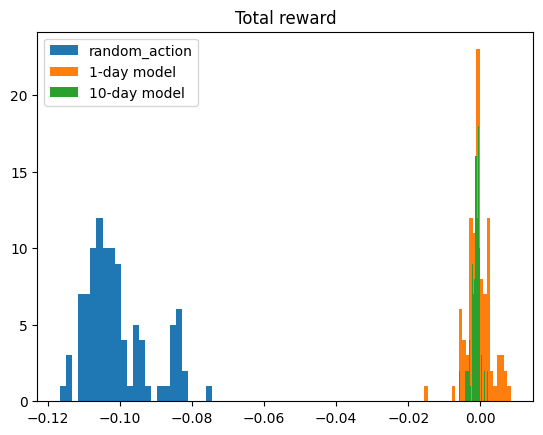

In [85]:
plt.hist([np.sum(x) for x in random_rewards], bins=25, label="random_action")
plt.hist([np.sum(x) for x in rewards_1d], bins=25, label="1-day model")
plt.hist([np.sum(x) for x in rewards_10d], bins=25, label="10-day model")
plt.legend()
plt.title("Total reward")
plt.show()

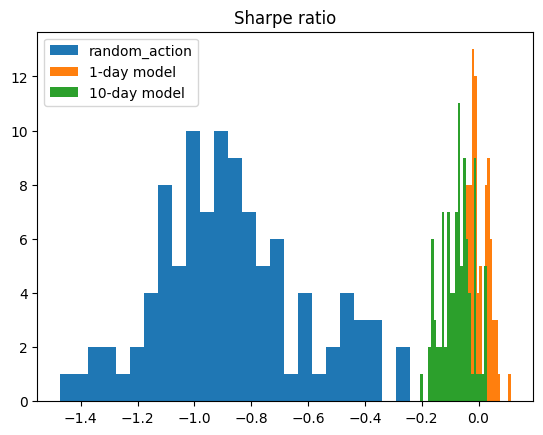

In [77]:
plt.hist(
    [np.mean(x) / np.std(x) for x in random_rewards], bins=25, label="random_action"
)
plt.hist([np.mean(x) / np.std(x) for x in rewards_1d], bins=25, label="1-day model")
plt.hist([np.mean(x) / np.std(x) for x in rewards_10d], bins=25, label="10-day model")
plt.legend()
plt.title("Sharpe ratio")
plt.show()

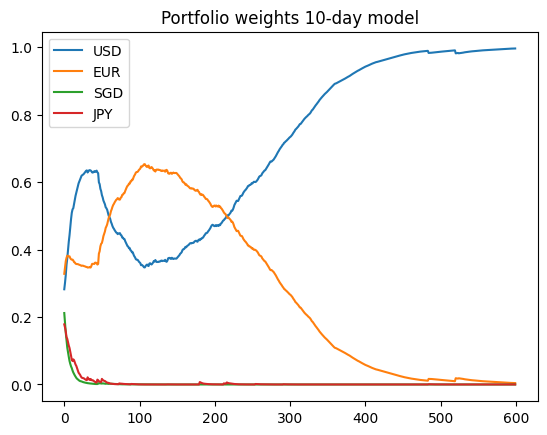

In [81]:
pd.DataFrame(pos_10d[-1]).plot()
plt.title("Portfolio weights 10-day model")
plt.show()

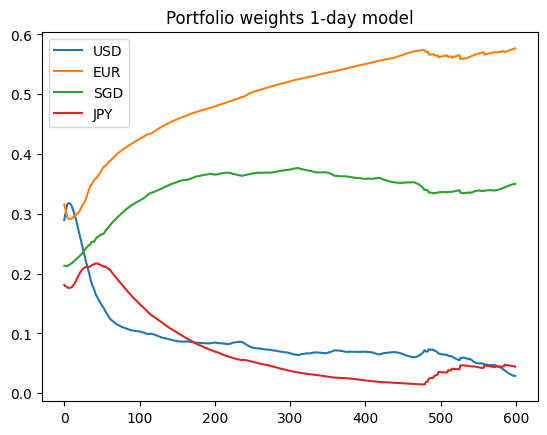

In [82]:
pd.DataFrame(pos_1d[-1]).plot()
plt.title("Portfolio weights 1-day model")
plt.show()

More stable positions in trading, some positive returns